In [1]:
import seaborn as sns
import requests
import pandas as pd
import numpy as np
from datetime import datetime
from astropy.time import Time
from LINZ.CORS_Timeseries import TimeseriesList, CoordApiTimeseries
import os 
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Define time range
start = datetime(2025, 1, 10)
end = datetime(2025, 1, 20)

In [3]:
code_mappings = {
    "Vcodes": "Trimble",
    "PPcodes": "Position_Partners",
    "EScodes": "Elliot_sinclair",
    "GScodes": "Global_Survey",
    "SYcodes": "Synergy",
    "SHcodes": "Survey_Hire"
}

# Print out the PositioNZ code to ensure it has worked
print("Vcodes =", code_mappings["Vcodes"])

Vcodes = Trimble


In [4]:
# Calculate crd_epoch
crd_epoch = end + (start - end) / 2
astropy_time_object = Time(crd_epoch, format='datetime')
crd_epoch_decimal_year = astropy_time_object.decimalyear

In [5]:
# The Trimble V codes are printed here:
#Vcodes=['VAK2',	'VALE',	'VCHR',	'VHAM',	'VHN2',	'VHRA',	'VLEE',	'VMAY',	'VNPE',	'VOMA',	'VOTG',	'VOTO',	'VPOA', 'VPRK',	'VPUK',	'VTEA',	'VTEK','VTEM', 'VWAN', 'VWKU', 'VWPK', 'VZQN','VOMA','VMKA',
#        'VSHF','VTES','VTOK','VWK2','VWM2','VPN2']


# The Position Partners codes are printed here: 
#PPcodes=['PPCW','PPNL','PPOR','PPPK','PPRS','PPSP','PPK2', 'PPMK']
#Inactive codes=[]


# The Elliot Sinclair codes are printed here: 
#EScodes=['ESBR','ESGM','ESKV','ESNL','ESPM','ESQT','ESRN','ESTR']
#Inactive codes=['ESCM']

# The Global Survey codes are printed here: 
#GScodes=['GSAA','GSAB','GSAM','GSAY','GSBA','GSBD','GSCC','GSCT','GSDA','GSDR','GSGR','GSHT','GSHU','GSHW','GSIN','GSKA','GSKK','GSLI','GSLW', 'GSLX','GSMG','GSOM','GSOK','GSPE','GSPL','GSPM','GSPN',
#         'GSPO','GSPR','GSPU','GSQT','GSRA','GSRL','GSRO','GSSB','GSTA','GSTH','GSTK','GSTU','GSTW','GSUH','GSUT','GSWI','GSWR','GSWU','GSNP','GSHO','GSGL','GSBN','GSBR','GSMA','GSMD','GSMO','GSPK',
#         'GSWA','GSMH','GSTI','GSWH']

# The Synergy codes are printed here: 
SYcodes=['SYAS','SYCC','SYCM','SYDF','SYHA','SYHW','SYM2','SYMV','SYNL','SYQN','SYT2','SYTA','SYTS','SYWM','SYET','SYBM','SYRD','SYLN','SYWK','SYPP','SYP2', 'SYOI', 'SYP3', 'SYPO', 'SYPR']

# Survey Hire codes are printed here: 
#SHcodes=['SHAR','SHMD','SHPA','SHML','SHSA']

In [6]:
# Initialise tracking set and output dictionary
stations_with_no_data = set()
group_dataframes = {}

# Define solution types to process
solution_types = [#"p20f_54_code", 
                  #"p20r_52_igs", 
                  "d20f_52_code_B"
                  #"d20f_54_code_A_G"
                  
                 ]

# Loop through all groups
for group_label, group_name in code_mappings.items():
    print(f"\nProcessing group: {group_label} ({group_name})")
    station_list = globals().get(group_label)
    if not station_list:
        print(f"⚠️ No station list found for {group_label}")
        continue

    # Prepare dictionary to hold data per solution type
    daily_avg_dfs = {sol: {} for sol in solution_types}

    for code in station_list:
        for sol in solution_types:
            try:
                print(f"  Processing station: {code} with solution: {sol}")
                ts = CoordApiTimeseries(code, solutiontype=sol, after=start, before=end)
                dates, xyz = ts.withoutOutliers().getObs(enu=False)

                df_obs = pd.DataFrame(xyz, columns=['x', 'y', 'z'], index=dates)
                df_obs['date'] = df_obs.index.strftime('%Y-%m-%d')
                df_obs['station'] = code
                df_obs['solutiontype'] = sol

                daily_avg_dfs[sol][code] = df_obs

            except Exception as e:
                print(f"    Failed to process station {code} with solution {sol}: {e}")
                stations_with_no_data.add((code, sol))

    # Combine and store DataFrames for each solution type
    for sol in solution_types:
        if daily_avg_dfs[sol]:
            sorted_codes = sorted(daily_avg_dfs[sol].keys())
            group_df = pd.concat([daily_avg_dfs[sol][code] for code in sorted_codes], axis=0)
            group_df.sort_values(by=["station", "date"], inplace=True)

            df_name = f"{group_label.replace('codes', '')}_{sol}_data"
            group_dataframes[df_name] = group_df

            print(f"{df_name} DataFrame created with shape: {group_df.shape}")
            print(f"Columns: {group_df.columns.tolist()}")
        else:
            print(f"⚠️ No data collected for group: {group_label} with solution: {sol}")




Processing group: Vcodes (Trimble)
⚠️ No station list found for Vcodes

Processing group: PPcodes (Position_Partners)
⚠️ No station list found for PPcodes

Processing group: EScodes (Elliot_sinclair)
⚠️ No station list found for EScodes

Processing group: GScodes (Global_Survey)
⚠️ No station list found for GScodes

Processing group: SYcodes (Synergy)
  Processing station: SYAS with solution: d20f_52_code_B
  Processing station: SYCC with solution: d20f_52_code_B
  Processing station: SYCM with solution: d20f_52_code_B
  Processing station: SYDF with solution: d20f_52_code_B
  Processing station: SYHA with solution: d20f_52_code_B
  Processing station: SYHW with solution: d20f_52_code_B
  Processing station: SYM2 with solution: d20f_52_code_B
  Processing station: SYMV with solution: d20f_52_code_B
  Processing station: SYNL with solution: d20f_52_code_B
  Processing station: SYQN with solution: d20f_52_code_B
  Processing station: SYT2 with solution: d20f_52_code_B
  Processing stati

In [7]:
# Define expected columns after conversion
converted_columns = [
    'x', 'y', 'z', 'date', 'station', 'solutiontype',
    'nztm_easting', 'nztm_northing', 'nzvd2016_elev'
]

# Create empty DataFrame to hold all converted data
PN_data_converted = pd.DataFrame(columns=converted_columns)

# Create empty DataFrames for each converted group
empty_converted_dfs = {
    f"{name}_converted": pd.DataFrame(columns=converted_columns)
    for name in group_dataframes
}

# Coordinate conversion function using LINZ OCC API
def convert_coordinates(input_crds, crd_epoch_decimal_year):
    occ_api = "https://www.geodesy.linz.govt.nz/api/conversions/v1/convert-to"
    coordlist = {
        "crs": "LINZ:ITRF2020_XYZ",
        "coordinateOrder": ["geocentricX", "geocentricY", "geocentricZ"],
        "coordinateEpoch": crd_epoch_decimal_year,
        "coordinates": input_crds
    }
    params = {"crs": "LINZ:NZTM/NZVD2016"}

    response = requests.post(occ_api, params=params, json=coordlist)
    if response.status_code == 200:
        converted = response.json()
        return converted['coordinateList']['coordinates']
    else:
        print(f"❌ API conversion failed with status {response.status_code}")
        print(f"🔍 Error details: {response.text}")
        return []

# Process each grouped DataFrame
for name, original_df in group_dataframes.items():
    print(f"\n🔄 Processing DataFrame: {name}")

    df = original_df.copy(deep=True)

    # Identify and report NaN and Inf values
    nan_values = df[df.isna().any(axis=1)]
    if not nan_values.empty:
        print(f" - Found {len(nan_values)} NaN rows")

    inf_values = df[(df == np.inf) | (df == -np.inf)].dropna(how='all')
    if not inf_values.empty:
        print(f" - Found {len(inf_values)} Inf rows")

    # Filter out invalid rows
    df_filtered = df.dropna(subset=['x', 'y', 'z']).copy()
    df_filtered = df_filtered[
        (df_filtered['x'] != np.inf) & (df_filtered['x'] != -np.inf) &
        (df_filtered['y'] != np.inf) & (df_filtered['y'] != -np.inf) &
        (df_filtered['z'] != np.inf) & (df_filtered['z'] != -np.inf)
    ]

    if df_filtered.empty:
        print(f"⚠️ Skipping {name} — no valid coordinates after filtering.")
        continue

    # Prepare coordinates for conversion
    input_crds = df_filtered[['x', 'y', 'z']].values.tolist()

    # Convert coordinates
    converted_coords = convert_coordinates(input_crds, crd_epoch_decimal_year)

    # Add converted coordinates to DataFrame
    if converted_coords:
        df_filtered[['nztm_easting', 'nztm_northing', 'nzvd2016_elev']] = pd.DataFrame(
            converted_coords, index=df_filtered.index
        )

        converted_name = f"{name}_converted"
        if converted_name in empty_converted_dfs:
            empty_converted_dfs[converted_name] = df_filtered
            print(f"✅ {converted_name} filled and updated.")
        else:
            print(f"⚠️ {converted_name} not found in empty_converted_dfs. Skipping storage.")
    else:
        print(f"❌ Conversion failed for {name}. No coordinates added.")



🔄 Processing DataFrame: SY_d20f_52_code_B_data
✅ SY_d20f_52_code_B_data_converted filled and updated.


In [8]:
# Finalise the dictionary of converted DataFrames
converted_group_dataframes = empty_converted_dfs.copy()

# Clean up the temporary variable if it's no longer needed
del empty_converted_dfs


In [9]:
# Identify networks that have all three solution types
networks = set()
for key in converted_group_dataframes.keys():
    if key.endswith("_converted"):
        parts = key.split("_")
        network = parts[0]
        networks.add(network)

# Loop through each network and compare the three solution types
for network in sorted(networks):
    key_f54 = f"{network}_p20f_54_code_data_converted"
    key_r52 = f"{network}_p20r_52_igs_data_converted"
    key_d52b = f"{network}_d20f_52_code_B_data_converted"

    if key_f54 not in converted_group_dataframes or key_r52 not in converted_group_dataframes or key_d52b not in converted_group_dataframes:
        continue

    df_f54 = converted_group_dataframes[key_f54]
    df_r52 = converted_group_dataframes[key_r52]
    df_d52b = converted_group_dataframes[key_d52b]

    # Convert date columns to datetime
    for df in [df_f54, df_r52, df_d52b]:
        df['date'] = pd.to_datetime(df['date'])

    # Find common stations across all three dataframes
    common_stations = set(df_f54['station']).intersection(df_r52['station'], df_d52b['station'])

    # Determine the overall date range
    start_date = min(df_f54['date'].min(), df_r52['date'].min(), df_d52b['date'].min())
    end_date = max(df_f54['date'].max(), df_r52['date'].max(), df_d52b['date'].max())
    #window_days = (end_date - start_date).days
    window_days = 30

    for station_name in sorted(common_stations):
        dfs = []
        for df, label in zip(
            [df_f54, df_r52, df_d52b],
            ['p20f_54_code', 'p20r_52_igs', 'd20f_52_code_B']
        ):
            station_df = df[df['station'] == station_name].sort_values('date').set_index('date')
            station_df['running_mean'] = station_df['nzvd2016_elev'].rolling(f'{window_days}D', min_periods=1).mean()
            station_df['detrended_mm'] = (station_df['nzvd2016_elev'] - station_df['running_mean']) * 1000
            station_df['solutiontype'] = label
            station_df['elevation'] = station_df['nzvd2016_elev']
            dfs.append(station_df)

        combined_df = pd.concat(dfs).reset_index()

        # Plotting
        sns.set(style="whitegrid")
        fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        sns.lineplot(data=combined_df, x='date', y='elevation', hue='solutiontype', ax=ax[0], alpha=0.6)
        sns.lineplot(data=combined_df, x='date', y='running_mean', hue='solutiontype', ax=ax[0], linewidth=2)
        ax[0].set_title(f'Elevation and Running Mean Comparison - {network} / {station_name}')
        ax[0].set_ylabel('Elevation (m)')
        ax[0].grid(True)

        sns.lineplot(data=combined_df, x='date', y='detrended_mm', hue='solutiontype', ax=ax[1])
        ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
        ax[1].set_title(f'Detrended Residuals Comparison - {network} / {station_name}')
        ax[1].set_xlabel('Date')
        ax[1].set_ylabel('Residuals (mm)')
        ax[1].grid(True)

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


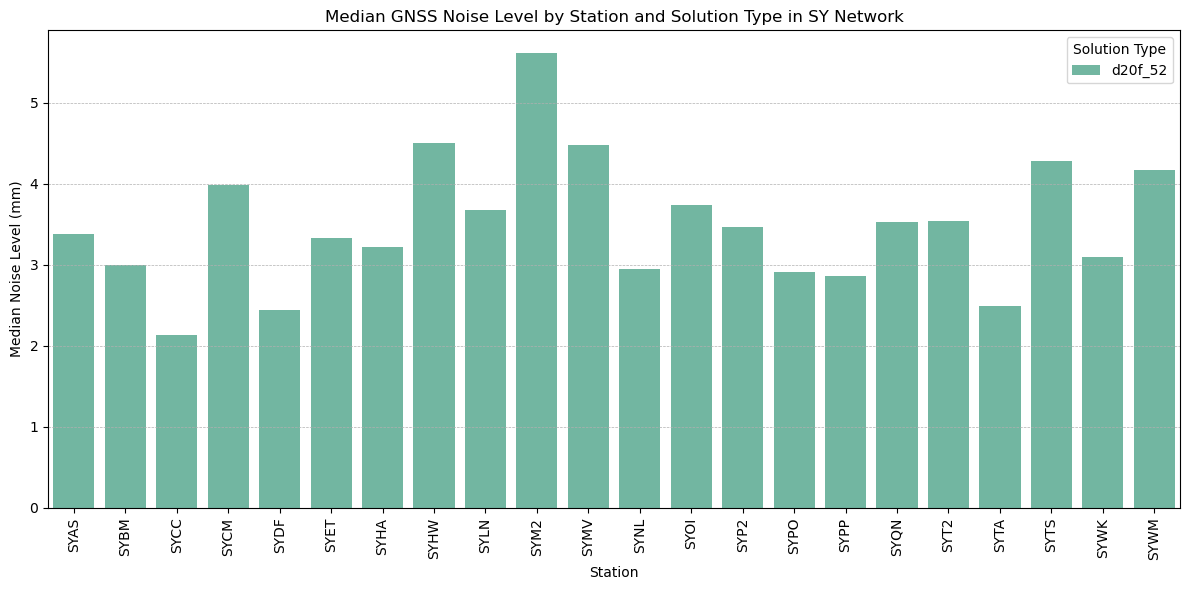

In [10]:
station_metrics = []

for network_name, df in converted_group_dataframes.items():
    if df.empty or 'nzvd2016_elev' not in df.columns or 'date' not in df.columns or 'station' not in df.columns:
        continue

    df['date'] = pd.to_datetime(df['date'])

    for station_name, station_df in df.groupby('station'):
        if station_df.empty:
            continue

        station_df = station_df.sort_values('date')
        station_df.set_index('date', inplace=True)

        window_days = (station_df.index.max() - station_df.index.min()).days
        station_df['running_mean'] = station_df['nzvd2016_elev'].rolling(f'{window_days}D', min_periods=1).mean()
        station_df['detrended_mm'] = (station_df['nzvd2016_elev'] - station_df['running_mean']) * 1000

        noise_std = station_df['detrended_mm'].std()
        acf_values = acf(station_df['detrended_mm'].dropna(), nlags=20, fft=True)

        parts = network_name.split('_')
        network = parts[0]
        solutiontype = '_'.join(parts[1:3]) if len(parts) >= 3 else 'unknown'

        station_metrics.append({
            'network': network,
            'station': station_name,
            'solutiontype': solutiontype,
            'noise_std_mm': noise_std,
            'acf_lag_1': acf_values[1] if len(acf_values) > 1 else None,
            'acf_lag_5': acf_values[5] if len(acf_values) > 5 else None,
            'acf_lag_10': acf_values[10] if len(acf_values) > 10 else None
        })

metrics_df = pd.DataFrame(station_metrics)

# Plot using seaborn: one plot per network

for network in metrics_df['network'].unique():
    network_df = metrics_df[metrics_df['network'] == network]
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=network_df,
        x='station',
        y='noise_std_mm',
        hue='solutiontype',
        palette="Set2"
    )
    plt.title(f'Median GNSS Noise Level by Station and Solution Type in {network} Network')
    plt.xlabel('Station')
    plt.ylabel('Median Noise Level (mm)')
    plt.xticks(rotation=90, ha='center')
    plt.legend(title='Solution Type')
    plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()



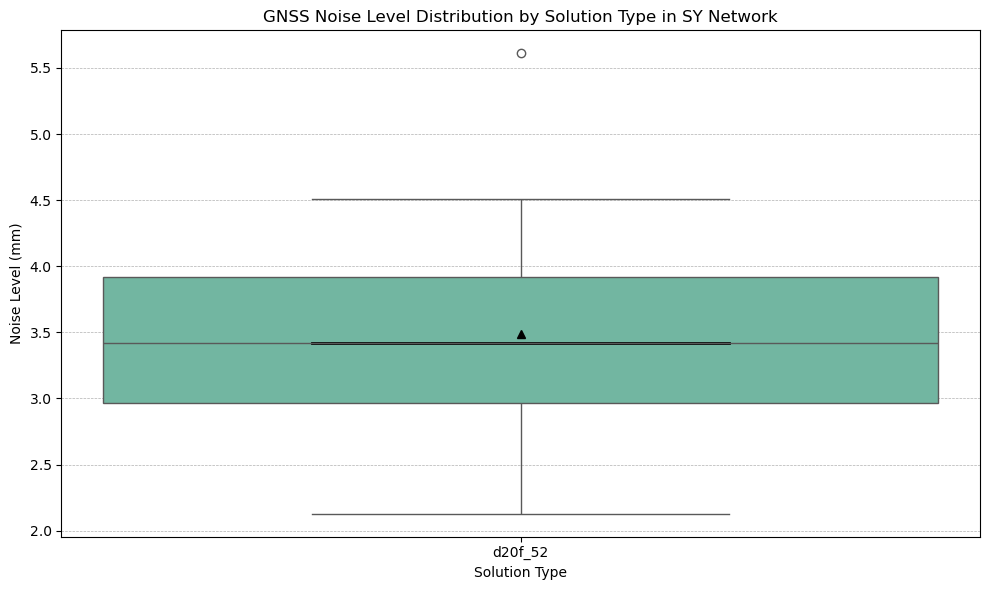

In [11]:
for network in metrics_df['network'].unique():
    network_df = metrics_df[metrics_df['network'] == network]
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(
        data=network_df,
        x='solutiontype',
        y='noise_std_mm',
        palette='Set2',
        hue='solutiontype',
        showmeans=True,
        meanprops={"marker": "^", "markerfacecolor": "black", "markeredgecolor": "black"}
    )

    # Overlay median lines manually
    medians = network_df.groupby('solutiontype')['noise_std_mm'].median()
    for tick, label in enumerate(ax.get_xticklabels()):
        solution = label.get_text()
        median_val = medians[solution]
        ax.plot([tick - 0.2, tick + 0.2], [median_val, median_val], color='black', linewidth=2)

    plt.title(f'GNSS Noise Level Distribution by Solution Type in {network} Network')
    plt.xlabel('Solution Type')
    plt.ylabel('Noise Level (mm)')
    plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

